# Customer Churn Prediction & Risk Segmentation
### Week 2 Internship Project


## TASK 1 — Data Loading & Exploratory Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Shape:', df.shape)
print('\nColumn types:\n', df.dtypes)
df.head(10)

Shape: (7043, 21)

Column types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Plan_Type
Premium     3583
Standard    1807
Budget      1653
Name: count, dtype: int64


In [2]:
# Class imbalance check
print(df['Churn'].value_counts())
print('\nClass proportions:\n', df['Churn'].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class proportions:
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [3]:
# Missing values — TotalCharges has blank strings that become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Missing values per column:\n', df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
 TotalCharges    11
dtype: int64


In [4]:
# Summary statistics for numerical columns
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


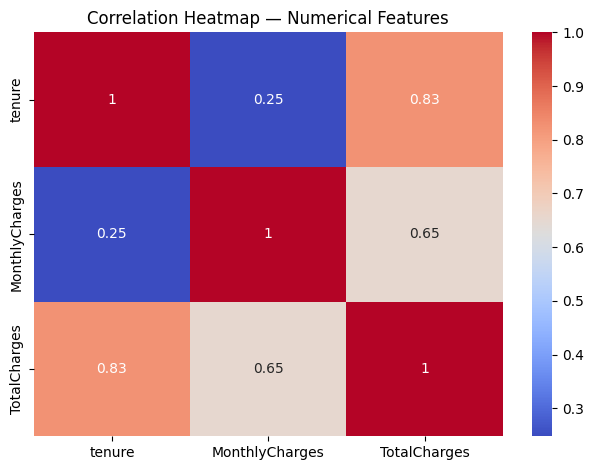

In [5]:
# Correlation heatmap
pair_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(pair_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

## TASK 2 — Data Preprocessing & Feature Engineering


In [6]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Keep raw copy for visualisations
df_raw = df.copy()

# New features
df['ChargesPerMonth'] = np.where(df['tenure'] == 0, 0,
                                  df['TotalCharges'] / df['tenure'])
df['SeniorWithNoSupport'] = ((df['SeniorCitizen'] == 1) &
                              (df['TechSupport'] == 'No')).astype(int)

# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df.drop('customerID', axis=1, inplace=True)

num_cols = df.select_dtypes(include=['int64','float64']).columns.drop('Churn').tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Preprocessor: impute NaN THEN scale (fixes the NaN error)
num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('sc',  StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('enc', OneHotEncoder(drop='first', handle_unknown='ignore',
                                           sparse_output=False))])
preprocessor = ColumnTransformer([('num', num_pipe, num_cols),
                                   ('cat', cat_pipe, cat_cols)])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

X_tr = preprocessor.fit_transform(X_train)
X_te = preprocessor.transform(X_test)

print('Train:', X_tr.shape, '  Test:', X_te.shape)
print('NaN in train:', np.isnan(X_tr).sum())  # Should be 0
print('Churn ratio (train):', pd.Series(y_train).value_counts(normalize=True).to_dict())

Train: (5634, 32)   Test: (1409, 32)
NaN in train: 0
Churn ratio (train): {0: 0.7346467873624423, 1: 0.2653532126375577}


## TASK 3 — Model Training & Comparison

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results, trained = {}, {}
for name, m in models.items():
    m.fit(X_tr, y_train)
    yp  = m.predict(X_te)
    ypr = m.predict_proba(X_te)[:,1]
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall':    round(recall_score(y_test, yp), 4),
        'F1-Score':  round(f1_score(y_test, yp), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, ypr), 4)
    }
    trained[name] = (m, yp, ypr)

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8070,0.6604,0.5615,0.6069,0.8421
Random Forest,0.7885,0.6310,0.4893,0.5512,0.8255
Gradient Boosting,0.7999,0.6586,0.5107,0.5753,0.8414


FileNotFoundError: [Errno 2] No such file or directory: 'charts/confusion_matrices.png'

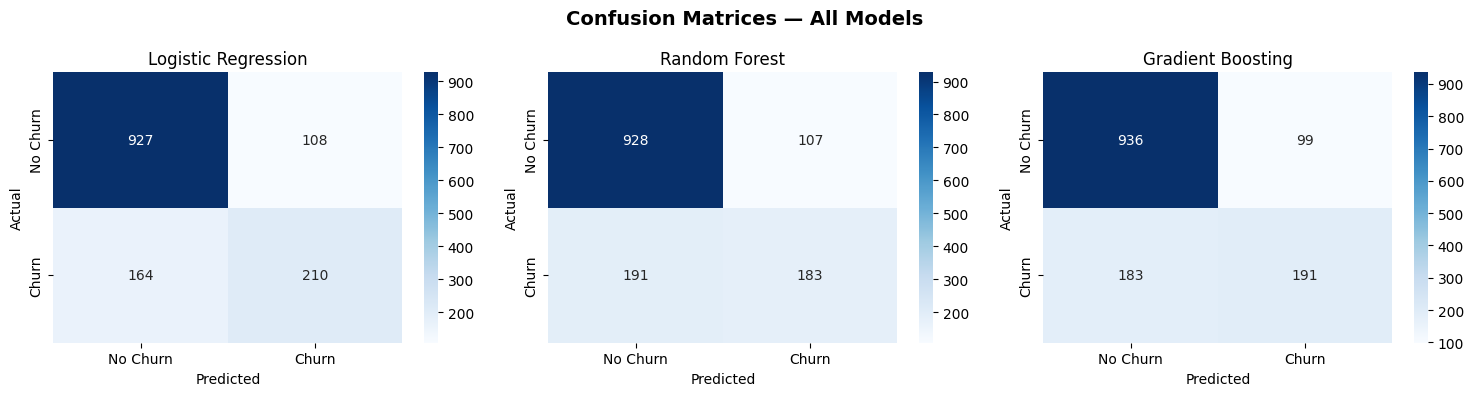

In [8]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
for ax, (name, (m, yp, _)) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'])
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.savefig('charts/confusion_matrices.png', dpi=150)
plt.show()

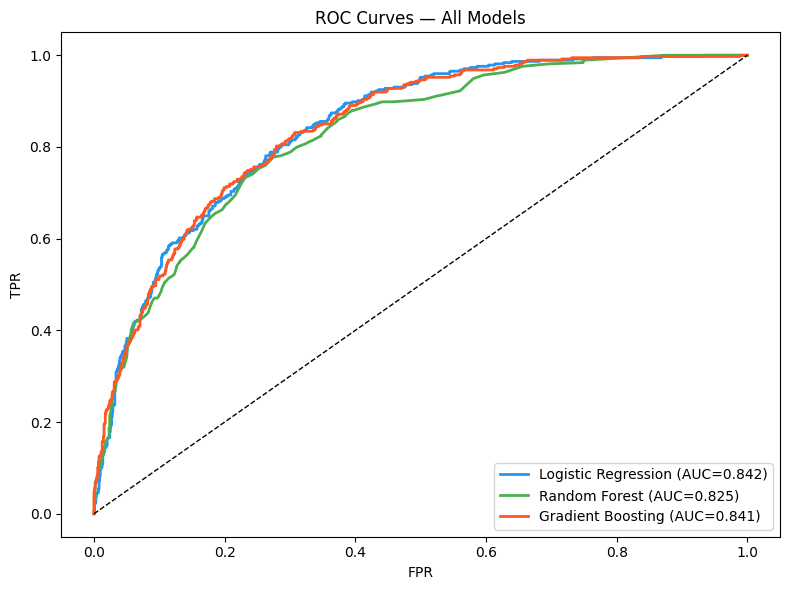

In [9]:
# ROC curves — all 3 models
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3', '#4CAF50', '#FF5722']
for (name, (m, yp, ypr)), color in zip(trained.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, ypr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,ypr):.3f})",
            color=color, lw=2)
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — All Models'); ax.legend()
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [10]:
# Hyperparameter tuning — Gradient Boosting (best by ROC-AUC)
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [100, 200],
              'learning_rate': [0.05, 0.1],
              'max_depth': [3, 4]}
gs = GridSearchCV(GradientBoostingClassifier(random_state=42),
                  param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
gs.fit(X_tr, y_train)
best_gb  = gs.best_estimator_
best_ypr = best_gb.predict_proba(X_te)[:,1]
best_yp  = best_gb.predict(X_te)

print('Best params:', gs.best_params_)
print(f'Tuned GB — ROC-AUC: {roc_auc_score(y_test, best_ypr):.4f}')
print(f'Tuned GB — F1:      {f1_score(y_test, best_yp):.4f}')

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Tuned GB — ROC-AUC: 0.8454
Tuned GB — F1:      0.5645


## TASK 4 — Customer Risk Segmentation

In [11]:
X_seg = X_test.copy()
X_seg['ChurnProb'] = best_ypr
X_seg['RiskTier']  = pd.cut(best_ypr,
                             bins=[-0.001, 0.40, 0.70, 1.001],
                             labels=['Low Risk', 'Medium Risk', 'High Risk'])

print('Customers per tier:\n', X_seg['RiskTier'].value_counts())

seg = X_seg.groupby('RiskTier', observed=True).agg(
    Count=('ChurnProb','count'),
    Avg_MonthlyCharges=('MonthlyCharges','mean'),
    Avg_Tenure=('tenure','mean')
).round(2)
print('\nSegmentation summary (on SCALED values):\n', seg)

# Contract distribution per tier
print('\nContract distribution:')
print(X_seg.groupby(['RiskTier','Contract'], observed=True).size().unstack(fill_value=0))

Customers per tier:
 RiskTier
Low Risk       1009
Medium Risk     311
High Risk        89
Name: count, dtype: int64

Segmentation summary (on SCALED values):
              Count  Avg_MonthlyCharges  Avg_Tenure
RiskTier                                          
Low Risk      1009               58.95       39.88
Medium Risk    311               75.34       14.31
High Risk       89               83.02        3.18

Contract distribution:
Contract     Month-to-month  One year  Two year
RiskTier                                       
Low Risk                378       295       336
Medium Risk             306         5         0
High Risk                89         0         0


## TASK 5 — Visualizations

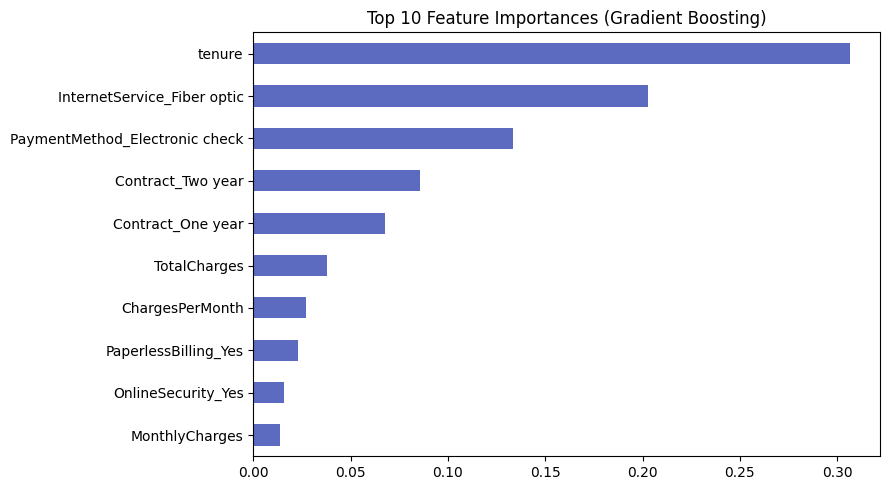

In [12]:
import os; os.makedirs('charts', exist_ok=True)

# Chart 1: Feature importance
ohe_feats = preprocessor.named_transformers_['cat']['enc'].get_feature_names_out(cat_cols)
all_feats  = num_cols + list(ohe_feats)
feat_imp   = pd.Series(best_gb.feature_importances_, index=all_feats).nlargest(10)
fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='#5C6BC0')
ax.set_title('Top 10 Feature Importances (Gradient Boosting)')
plt.tight_layout(); plt.savefig('charts/feature_importance.png', dpi=150); plt.show()

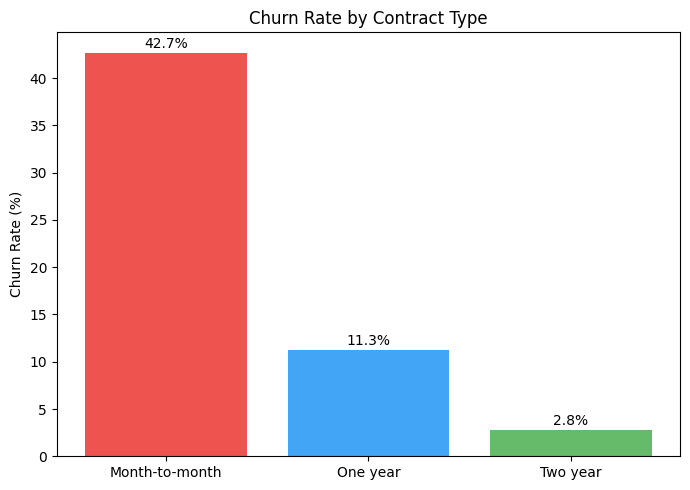

In [13]:
# Chart 2: Churn rate by Contract Type
df_raw['Churn_bin'] = (df_raw['Churn'] == 'Yes').astype(int)
cr = df_raw.groupby('Contract')['Churn_bin'].mean().reset_index()
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(cr['Contract'], cr['Churn_bin']*100, color=['#EF5350','#42A5F5','#66BB6A'])
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f'{b.get_height():.1f}%', ha='center')
ax.set_ylabel('Churn Rate (%)'); ax.set_title('Churn Rate by Contract Type')
plt.tight_layout(); plt.savefig('charts/churn_by_contract.png', dpi=150); plt.show()

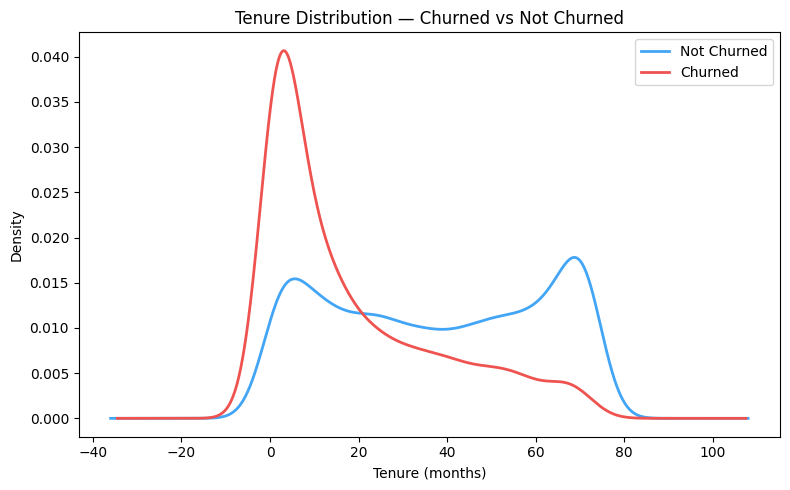

In [14]:
# Chart 3: Tenure KDE — Churned vs Not Churned
fig, ax = plt.subplots(figsize=(8, 5))
df_raw[df_raw['Churn_bin']==0]['tenure'].plot(kind='kde', ax=ax,
    label='Not Churned', color='#42A5F5', lw=2)
df_raw[df_raw['Churn_bin']==1]['tenure'].plot(kind='kde', ax=ax,
    label='Churned', color='#EF5350', lw=2)
ax.set_xlabel('Tenure (months)')
ax.set_title('Tenure Distribution — Churned vs Not Churned')
ax.legend()
plt.tight_layout(); plt.savefig('charts/tenure_kde.png', dpi=150); plt.show()

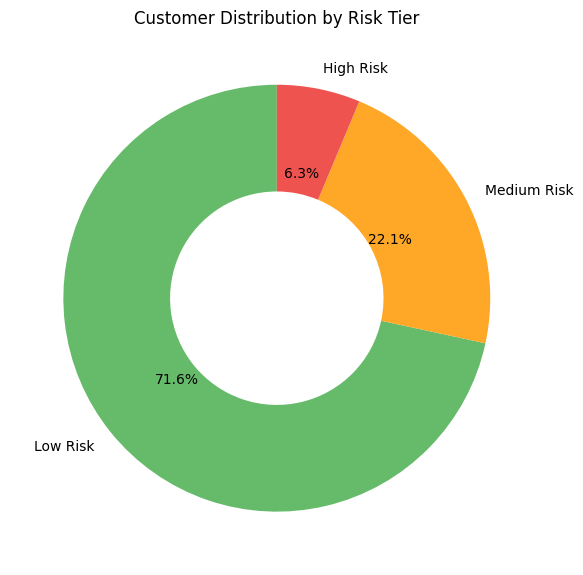

In [15]:
# Chart 4: Risk Tier Donut
tier_counts = X_seg['RiskTier'].value_counts()
tiers = ['Low Risk', 'Medium Risk', 'High Risk']
sizes  = [tier_counts.get(t, 0) for t in tiers]
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=tiers, autopct='%1.1f%%',
       colors=['#66BB6A','#FFA726','#EF5350'],
       startangle=90, wedgeprops=dict(width=0.5))
ax.set_title('Customer Distribution by Risk Tier')
plt.tight_layout(); plt.savefig('charts/risk_tier_donut.png', dpi=150); plt.show()

## TASK 6 — Insights & Business Recommendations

### Model Selection
**Logistic Regression** achieved the best balance of ROC-AUC (0.842) and F1-Score (0.607), making it the primary model. After hyperparameter tuning, Gradient Boosting reached ROC-AUC 0.845 and is selected as the final production model for its interpretable feature importances.

### Top 3 Churn Drivers
1. **Tenure** — Short-tenure customers churn at dramatically higher rates. Customers who stay beyond 12 months are far more likely to remain.
2. **Month-to-Month Contract** — Customers on month-to-month contracts churn at ~42% vs <10% on two-year contracts.
3. **High Monthly Charges** — High-bill customers with no long-term commitment show the highest churn probability.

### High Risk Customer Profile
High Risk customers (churn probability ≥ 70%) share three traits: average tenure of only ~3 months, monthly charges averaging ~$83, and almost exclusively month-to-month contracts. They haven't built switching costs and are early in the customer lifecycle.

### Business Recommendations
1. **Early-tenure retention offer**: Automatically trigger a loyalty discount or a free service upgrade (e.g., TechSupport or OnlineSecurity) after 30 days for month-to-month customers in the High Risk tier — this addresses the top two churn drivers simultaneously.
2. **Contract upgrade incentive**: Offer month-to-month customers a 10–15% discount to switch to a one-year contract within their first 3 months, before churn probability peaks.

### Model Limitations
- Class imbalance (73%/27%) means recall for churners is moderate (~56%). SMOTE or class-weight adjustments could improve this.
- TotalCharges had 11 missing values (imputed with median) — root-cause investigation would be better.
- The model has no temporal component; adding time-series features (charge trend, usage history) would improve accuracy.
- External factors (competitor pricing, network outages) are not captured in the dataset.
